 # Analyse du désabonnement des clients (Customer churn)

 ### Télecom Customer Churn
 **Objectif :**
 
 Analyser les données clients d'un operateur télecom pour comprendre les causes du désabonnement (churn)et repondre aux questions business suivantes :
 
     1. A quoi ressemble le clientèle ?
     2. Quels sont les segement présantant le taux de désabonnement le plus élevé
     3. Le type de contrat a t'il une infliuence sur la fidélisation ?
     4. la durée d'ancienneté a-t-elle un impact sur la fidélité ?
     5. Quels sont les services qui influences le taux de désabonnement ?
     6. Quel mode de paiement présente un taux de désabonnement le plus élevé?
     7. Quelle muesure la direction devrait-elle prendre?


 **Plan du travail :**
 
     1. Importation des packages
     2. Chargement des données
     3. Inspection des données 
     4. Netoyage des données
     5. Analyse et reponse aux questions business
     6. Synthese et Recommandation

1. Importaion des bilblioteques

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#Style du graphique 
sns.set_theme(style = "whitegrid", font_scale = 1.05)
plt.rcParams['figure.dpi'] =  100

# les coleurs (fidele vs resilises)
COL_NO, COL_YES = '#4c72B0', '#DD5A5A'


## 2. Chargement des données

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Inspection des données

- les dimensions (lignes / colonnes),
- les types de données,
- les valeurs manquantes,
- les doublons,
- les statistiques descriptives.

### 3.1 Dimensions

In [5]:
print(f"Nombre de lignes (clients)  : {df.shape[0]}")
print(f"Nombre de colonnes (variables) : {df.shape[1]}")

Nombre de lignes (clients)  : 7043
Nombre de colonnes (variables) : 21


### 3.2 Types de données



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 3.3 Valeurs manquantes

À première vue, il n'y a pas de valeurs ,anquantes

In [172]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
ChurnBin            0
SeniorLabel         0
dtype: int64

...mais la colonne TotalCharges est importée comme du texte (object) alors qu'elle devrait être numérique.

In [177]:
# On convertir TotalCharges en numérique ; ce qui ne peut pas être converti devient NaN
totalcharges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Valeurs non convertibles en nombre :", totalcharges_numeric.isna().sum())

# On regarde ces lignes problématiques
df[totalcharges_numeric.isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Valeurs non convertibles en nombre : 0


,customerID,tenure,MonthlyCharges,TotalCharges


 **Constat :** les 11 valeurs vides de TotalCharges correspondent toutes à des clients avec tenure = 0 : ce sont des clients tout juste arrivés, qui n'ont pas encore reçu de première facture. 

### 3.4 Doublons

In [9]:
print("Lignes complètement dupliquées :", df.duplicated().sum())
print("Identifiants client (customerID) dupliqués :", df['customerID'].duplicated().sum())

Lignes complètement dupliquées : 0
Identifiants client (customerID) dupliqués : 0


 Aucun doublon : chaque ligne est bien un client unique.

### 3.5 Valeurs uniques des variables catégorielles

 pour repérer des fautes de saisie, des catégories inattendues, etc.

In [10]:
for col in df.select_dtypes(include='object').columns:
    if col != 'customerID':
        print(f"{col:20s} -> {df[col].unique()}")

gender               -> ['Female' 'Male']
Partner              -> ['Yes' 'No']
Dependents           -> ['No' 'Yes']
PhoneService         -> ['No' 'Yes']
MultipleLines        -> ['No phone service' 'No' 'Yes']
InternetService      -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity       -> ['No' 'Yes' 'No internet service']
OnlineBackup         -> ['Yes' 'No' 'No internet service']
DeviceProtection     -> ['No' 'Yes' 'No internet service']
TechSupport          -> ['No' 'Yes' 'No internet service']
StreamingTV          -> ['No' 'Yes' 'No internet service']
StreamingMovies      -> ['No' 'Yes' 'No internet service']
Contract             -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling     -> ['Yes' 'No']
PaymentMethod        -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges         -> ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn                -> ['No' 'Yes']


### 3.6 Statistiques descriptives

Pour les variables numériques :

In [11]:
df[['tenure', 'MonthlyCharges']].describe().round(2)

,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


### 3.7 Distribution de la variable cible Churn

In [12]:
print(df['Churn'].value_counts())
print()
print((df['Churn'].value_counts(normalize=True) * 100).round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


 **26,5 % des clients ont résilié.** C'est un déséquilibre de classes assez fort normal pour ce type de problème 

## 4. Nettoyage des données

Sur la base du diagnostic précédent, deux actions de nettoyage sont nécessaires :

1. **Convertir TotalCharges en numérique** et imputer les 11 valeurs manquantes par **0** (cohérent : ce sont des clients avec **tenure = 0**, donc pas encore facturés).
2. **Créer quelques colonnes utilitaires** pour faciliter l'analyse (variable binaire du churn, libellé du statut senior).

On ne supprime aucune ligne : avec seulement 11 valeurs sur 7 043 (0,16 %)

In [23]:
#charnger le TotalCharge en numerique et impute 0 les valeurs manquantes
df['TotalCharges'] = pd.to_numeric (df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

#colonne utilitaire 1= fidele 0 = resilie
df['ChurnBin'] = (df['Churn'] == 'Yes').astype(int) 
df['SeniorLabel'] = df['SeniorCitizen'].map({0: 'Non senior' , 1: 'Senior'})

## 5. Analyse et reponses aux questions business
---

### Question 1 : A quoi ressemble la clientèls ?
on regarde d'abord le profil démographique ( age, genre, situation familiale) puis l'ancienneté et les charges mensuelles

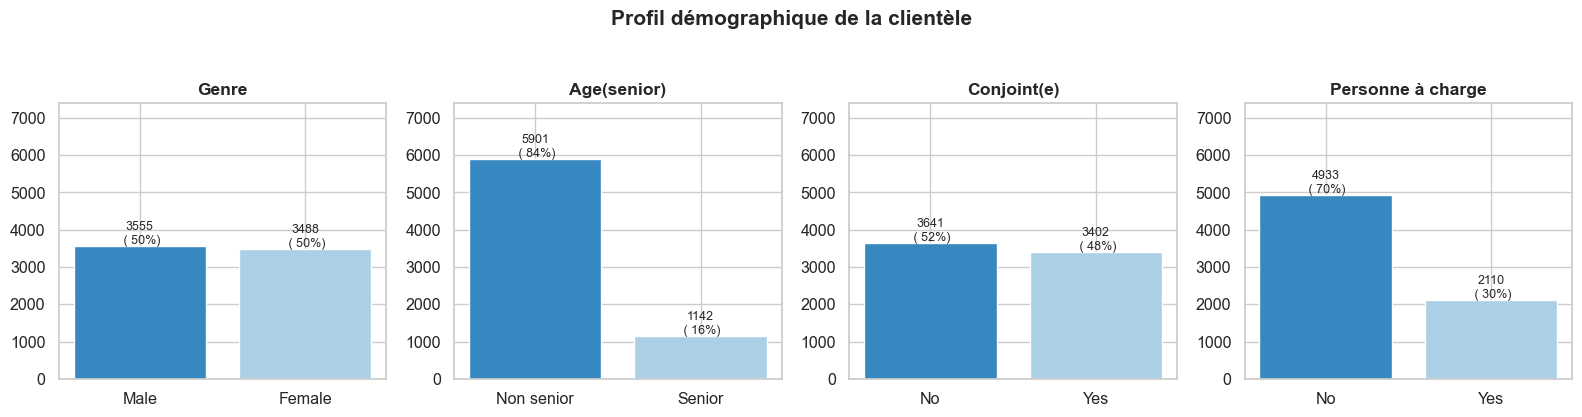

In [180]:
fig,axes = plt.subplots(1, 4, figsize = (16 , 4))
profile_cols = [('gender' , 'Genre'), ('SeniorLabel', 'Age(senior)'), 
               ('Partner', 'Conjoint(e)'), ('Dependents','Personne à charge')]
for ax, (col, title) in zip(axes, profile_cols):
    vc = df[col].value_counts()
    bar = ax.bar(vc.index.astype(str),vc.values, color= sns.color_palette(('Blues_r'), len(vc)))
    for b, c in zip (bar, vc.values) :
        ax.text(b.get_x() + b.get_width()/2, c + 60, f"{c}\n ({c/len(df)*100 : .0f}%)", ha = 'center', fontsize = 9)
        ax.set_title(title, fontweight='bold')
        ax.set_ylim(0 ,len(df)*1.05)



fig.suptitle("Profil démographique de la clientèle", fontweight = 'bold' , y = 1.04)
plt.tight_layout()
plt.show()
                 
                    

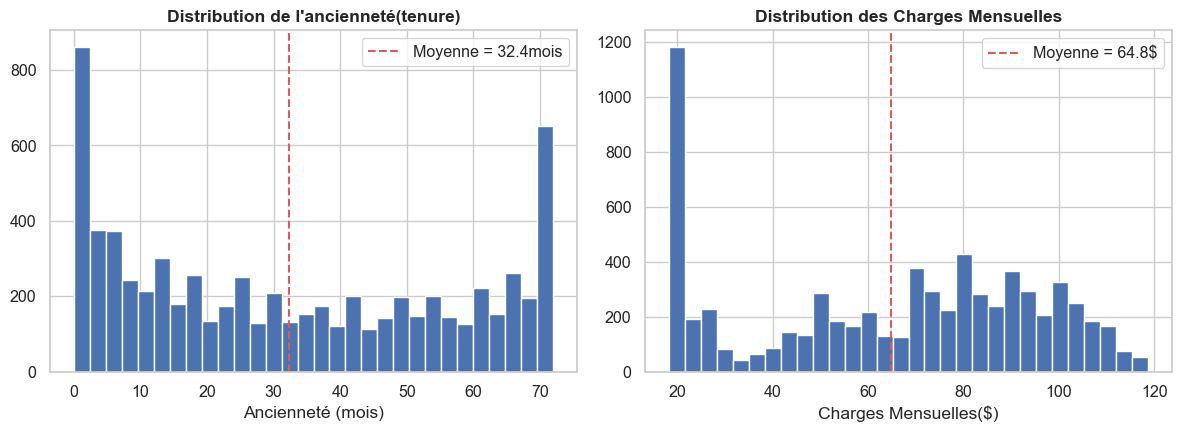

In [181]:
##Histogramme de tenure

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))
axes[0].hist(df['tenure'],bins = 30, color = COL_NO, edgecolor = 'white')
axes[0].axvline(df['tenure'].mean(), color = COL_YES, ls = '--', label=f"Moyenne = {df['tenure'].mean() :.1f}mois")
axes[0].set_title("Distribution de l'ancienneté(tenure)", fontweight = 'bold')
axes[0].set_xlabel("Ancienneté (mois)"); axes[0].legend()

##histogramme de MonthlyCharges
axes[1].hist(df['MonthlyCharges'],  bins = 30, color = COL_NO, edgecolor = 'white')
axes[1].axvline(df['MonthlyCharges'].mean(), color= COL_YES, ls = '--', 
                 label = f"Moyenne = {df['MonthlyCharges'].mean():.1f}$")
axes[1].set_title("Distribution des Charges Mensuelles", fontweight = 'bold')
axes[1].set_xlabel("Charges Mensuelles($)");axes[1].legend()

plt.tight_layout()
plt.show()
    
                        

In [66]:
contract_pct=df['Contract'].value_counts(normalize = True)*100
contract_pct

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

**Interpretation**
- Profil demographique de la clientèle **équilibré** : 50% d'homme(mâle) et 50% de femme (female), 16% de senior,
  48 % en couple, 30 % de personne en charge ce qui montre qu'il n'y a pas de biais démographique particulier.
  
- L'ancienneté **n'est pas centrer**: Beaucoup de clients très récent de (0-12 Mois) et un autre groupe de clients 
  très enciennes (~ 70 mois). Ancienneté moyenne = **32,4 mois**.

- Les charges mensuelles vont de 18 $ a 119$ (moyenne **64,8$**) avec un pic vers 20$ (clients "téléphone seul").

- **55 % de client sont en contrat mensuel** (sans engagement) un point clé pour la suite



---
### Question 2 : Quels segments presentent le taux de désabonnement le plus élevé?
 on va calculer le taux de chur (en % de 'YES') pour les principales variables catégorielles, et on trie du plus risqué au moins risqué. C'est le reflexe de base pour repérer rapidement les segments à vérifier.

In [75]:
def taux_churn_par(col):
    """Retourne le taux de desabonnement (%) et l'effectif pour chaque categories de colonne"""
    g = df.groupby(col, observed = True)['ChurnBin'].agg(taux_churn = 'mean', effectif = 'count')
    g['taux_churn'] = (g['taux_churn']*100).round(1)
    return g.sort_values('taux_churn', ascending = False)

##on regarde pour plusieurs variable d'un coup
for col in ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'OnlineSecurity',
            'TechSupport', 'PaperlessBilling']:
    print(f"\n--{col}---")
    print(taux_churn_par(col))



--Contract---
                taux_churn  effectif
Contract                            
Month-to-month        42.7      3875
One year              11.3      1473
Two year               2.8      1695

--InternetService---
                 taux_churn  effectif
InternetService                      
Fiber optic            41.9      3096
DSL                    19.0      2421
No                      7.4      1526

--PaymentMethod---
                           taux_churn  effectif
PaymentMethod                                  
Electronic check                 45.3      2365
Mailed check                     19.1      1612
Bank transfer (automatic)        16.7      1544
Credit card (automatic)          15.2      1522

--SeniorCitizen---
               taux_churn  effectif
SeniorCitizen                      
1                    41.7      1142
0                    23.6      5901

--OnlineSecurity---
                     taux_churn  effectif
OnlineSecurity                           
No         

### **Interprétation des segments les plus à risque :**
 | segement  | taux de churn |
 |---|---|
 | Electronic check | 45,3 % |
 | Month-to-month | 42,7 % |
 | Internet fiber optic | 41,9 % |
 | Online security| 41,8 % |
 | Senior Citizen| 41,7 %|
 | No tech support | 41,6 % |
 | Paper less billing | 33,6 % |


A l'inverse, les plus fidèles : ontract two year (2,8 %), No internet service (7,4 %), Credit card(automatic) (15,2 %).

     Le risque de désabonnement est plus élevé chez les clients les moins <<engagés>> (contrat court, paiement manuel, peu de service complémentaires).

---
## Question 3 : Le type de contrat a t'il un influence sur la fidélisation ?

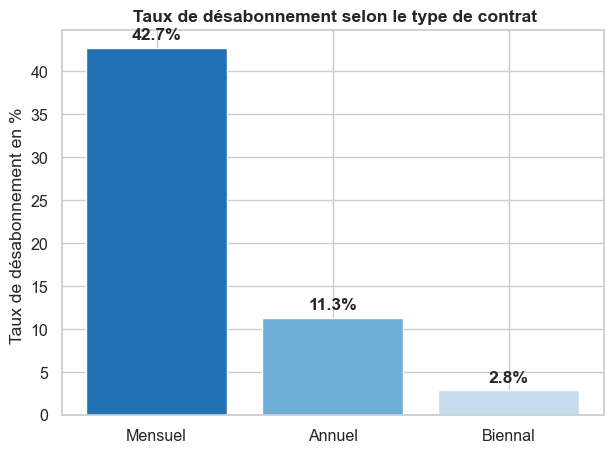

In [182]:
order = ['Month-to-month', 'One year', 'Two year']
label = ['Mensuel', 'Annuel', 'Biennal']
taux = df.groupby('Contract', observed = True)['ChurnBin'].mean().reindex(order)*100

fig, ax = plt.subplots(figsize = (7, 5))
bars = ax.bar(label, taux.values , color = sns.color_palette("Blues_r", 3))
for b , v in zip(bars, taux.values):
    ax.text(b.get_x()  + b.get_width()/2, v + 1 , f"{v:.1f}%", ha = 'center', fontweight = 'bold')
ax.set_ylabel('Taux de désabonnement en % ')
ax.set_title(" Taux de désabonnement selon le type de contrat", fontweight = 'bold')
plt.show() 

In [183]:
# Corelation entre l'engagement contratuel ( 0 = Mensuel, 1 = Annuel, 2 = Biennel) et pour churn
contract_ord = df['Contract'].map({'Month-to-month' : 0, 'One year' : 1, 'Two year': 2})
print("Corrélation Contrat  Churn :", round(contract_ord.corr(df['ChurnBin']), 2))
      

Corrélation Contrat  Churn : -0.4


#### **Interprétation** : 
Le contract est **le facteur le plus déterminant** de l'analyse. Le churn passe de **42,7 %** (Mensuel) à **11,3 %** (Annuel) puis 2,8%(biennal) un rapport de 1 a 15. Corrélation : **- 0,40**, la plus forte observée. Un contrat sans engagement peut etre résilié.

-----------
## Question 4 : La durée d'ancienneté a-t-elle un impact sur la fidélité ?

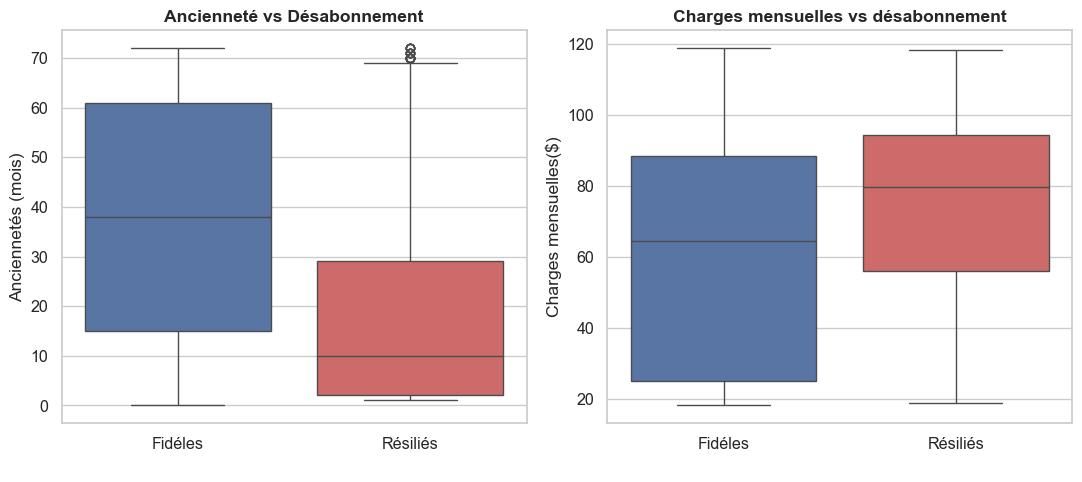

In [186]:
fig, axes = plt.subplots(1, 2, figsize = (11, 5))
sns.boxplot( x = 'Churn' , y= 'tenure', data = df, order = ['No', 'Yes'],
             hue = 'Churn', palette=[COL_NO, COL_YES], legend = False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Fidéles' , 'Résiliés'])
axes[0].set_title("Ancienneté vs Désabonnement", fontweight = 'bold')
axes[0].set_xlabel(' '); axes[0].set_ylabel('Anciennetés (mois)')

sns.boxplot( x = 'Churn', y = 'MonthlyCharges', data = df, order = ['No', 'Yes'],
             hue = 'Churn', palette=[COL_NO, COL_YES], legend = False, ax = axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Fidéles', 'Résiliés'])
axes[1].set_title("Charges mensuelles vs désabonnement", fontweight = 'bold')
axes[1].set_xlabel(' '); axes[1].set_ylabel('Charges mensuelles($)')

plt.tight_layout()
plt.show()



In [187]:
print(df.groupby('Churn')['tenure'].agg(['mean', 'median']).round(1))
print()
print("Corrélation ancienneté Churn :", round(df['tenure'].corr(df['ChurnBin']), 2))
pct_early= (df[df['Churn']=='Yes']['tenure'] <= 6).mean()*100
print(f" Les clients résiliés partis dans les 6 premiers mois : {pct_early:.1f}%")
    

       mean  median
Churn              
No     37.6    38.0
Yes    18.0    10.0

Corrélation ancienneté Churn : -0.35
 Les clients résiliés partis dans les 6 premiers mois : 41.9%


**Interpretation** :
L'ancienneté médian des résiliés n'est que de **10 mois**, contre **38 mois** pour les fidéles (corrélation **-0,35**). Près de 42 % des résiliations ont eu lieu dans les 6 premiers mois une veritable **<<Zone de danger>>** en début de relation client. Autre point important : les clients qui partent payent en moyenne **plus cher**(74,4 vs 61,3) ce ne sont donc pas les clients les moins rentables qu'on perd 

-----
## Question 5 : Quels sont les services qui influences le taux de désabonnement ?


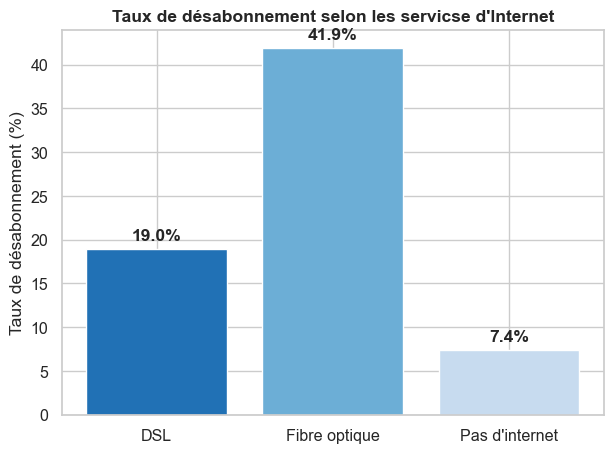

In [188]:
order = ['DSL','Fiber optic', 'No']
labels=["DSL", "Fibre optique", "Pas d'internet"]
taux = df.groupby('InternetService', observed = True)['ChurnBin'].mean().reindex(order)*100

fig, ax =plt.subplots(figsize = (7, 5))
bars = ax.bar(labels, taux.values, color= sns.color_palette("Blues_r", 3))
for b, v in zip(bars, taux.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v :.1f}%", ha = 'center', fontweight = 'bold')
    ax.set_ylabel("Taux de désabonnement (%)")
    ax.set_title("Taux de désabonnement selon les servicse d'Internet", fontweight = 'bold')
plt.show()


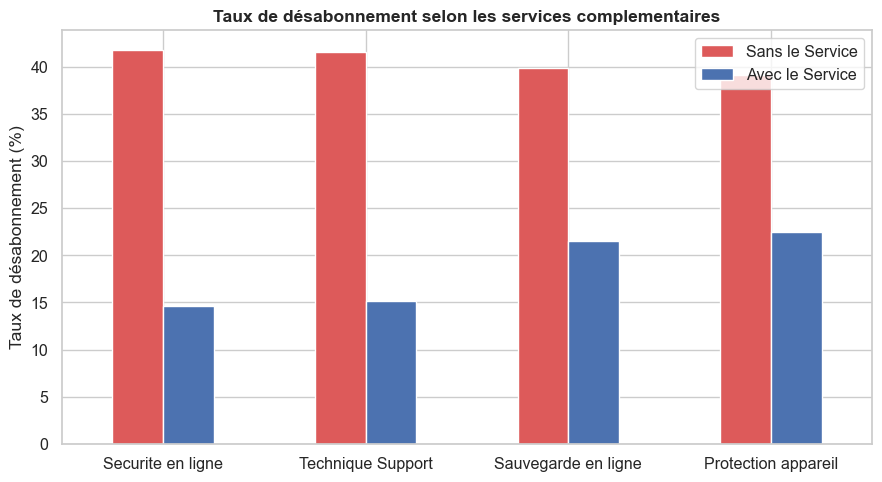

,Sans le Service,Avec le Service
Securite en ligne,41.8,14.6
Technique Support,41.6,15.2
Sauvegarde en ligne,39.9,21.5
Protection appareil,39.1,22.5


In [189]:
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
label_fr = ['Securite en ligne', 'Technique Support', 'Sauvegarde en ligne', 'Protection appareil']

rows = []
for s in services:
    sub = df[df[s].isin(['Yes', 'No'])]
    g = sub.groupby(s, observed = True)['ChurnBin'].mean()*100
    rows.append([g.get('No', 0) ,g.get('Yes', 0)])
gdf = pd.DataFrame(rows, index=label_fr, columns = ['Sans le Service', 'Avec le Service']).round(1)

ax = gdf.plot(kind = 'bar', figsize = (9, 5 ), color = [COL_YES, COL_NO], rot = 0)
ax.set_ylabel("Taux de désabonnement (%)")
ax.set_title("Taux de désabonnement selon les services complementaires", fontweight = 'bold')
plt.tight_layout()
plt.show()
gdf
             
                


### **Interprétation :**
- Paradoxe fibre optique : les clients fibre résilient à **41, 9 %**, plus de double des clients DSL (19 %) alors que la fibre est le produit le plus premium(corrélation de 0,79 avec les charges mensuelles). Signal probable de problème qualité/prix.
- Les services complémentaires ont un **fort effet protecteur** : sans "sécurité en ligne", le Churn est de **41,8 %** contre **14,6 %** avec un écart de plus de 27 points, similaire pour le support technique. Ces services sont un vrai levier de retention , pas juste un revenu additionnel.

----
## Question 6 : Quels mode de payement présentent un taux de désabonement le plus élevé?



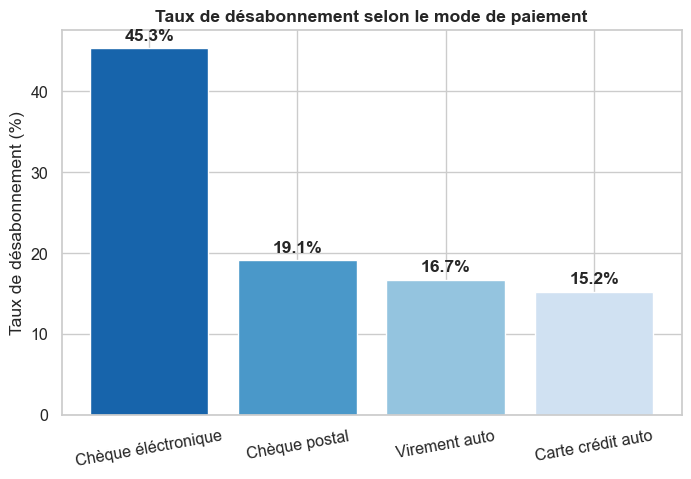

In [192]:
order = ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
labels = ['Chèque éléctronique', 'Chèque postal', 'Virement auto', 'Carte crédit auto']
taux = df.groupby('PaymentMethod', observed = True)['ChurnBin'].mean().reindex(order)*100

fig, ax = plt.subplots(figsize = (8, 5))
bars = ax.bar(labels, taux.values, color=sns.color_palette("Blues_r", 4))
for b, v in zip(bars, taux.values):
    ax.text(b.get_x() +b.get_width()/2, v + 1, f"{v:.1f}%", ha = 'center', fontweight = 'bold')
ax.set_ylabel("Taux de désabonnement (%)")
ax.set_title("Taux de désabonnement selon le mode de paiement", fontweight= 'bold')
plt.xticks(rotation = 10)
plt.show()
            

### **Interprétation :** 
Le chèque éléctronique est associé au churn le plus élevé **(45,3 %)**, près de 3 fois plus que le payement automatique par carte                   **(15,2 %)** ou virement **(16,7 %)**. Le paiement automatique traduit une relation plus "Installée" ; le paiement annuel laisse au client une occasion régulière de reconsidérer son abonnement.

-----
## Synthèse : carte de corrélation
On encode les variables clés en numérique (0/1 pour les bouléens, ordinal pour les contrats) pour visualiser leur corrélation avec le churn

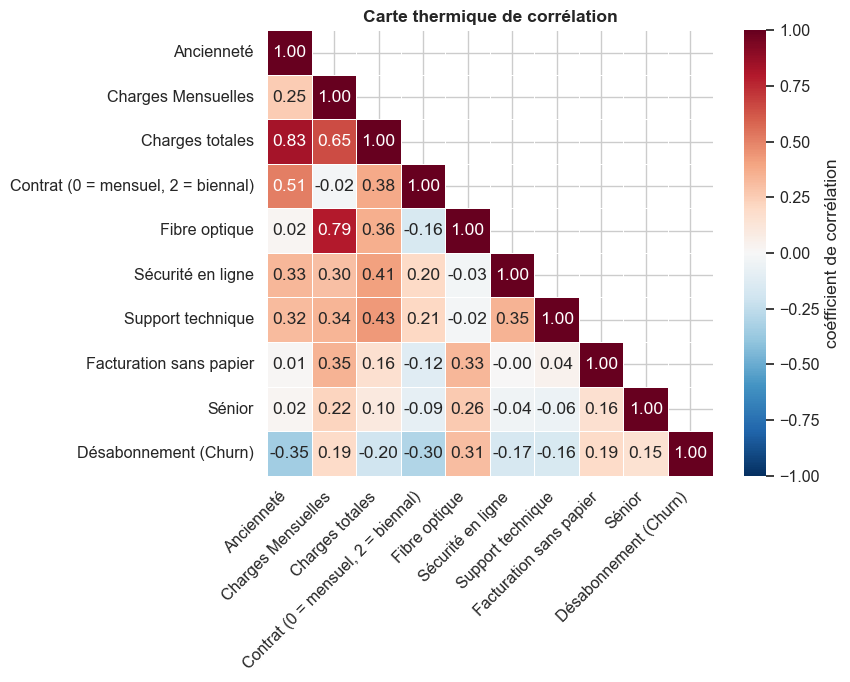

In [193]:
enc = pd.DataFrame(index = df.index)
enc['Ancienneté'] = df['tenure']
enc['Charges Mensuelles'] = df['MonthlyCharges']
enc['Charges totales'] = df['TotalCharges']
enc['Contrat (0 = mensuel, 2 = biennal)'] = df['Contract'].map({'Month-to-month' : 0, 'One year':1, 'two year':2})
enc['Fibre optique'] = (df['InternetService']=='Fiber optic').astype(int)
enc['Sécurité en ligne'] = (df['OnlineSecurity'] == 'Yes').astype(int)
enc['Support technique'] = (df['TechSupport'] == 'Yes').astype(int)
enc['Facturation sans papier'] = (df['PaperlessBilling'] == 'Yes').astype(int)
enc['Sénior'] = df['SeniorCitizen']
enc['Désabonnement (Churn)'] = df['ChurnBin']

corr = enc.corr().round(2)
plt.figure(figsize = (9, 7))
mask = np.triu(np.ones_like(corr, dtype = bool),k = 1)
sns.heatmap (corr, mask = mask, cmap = 'RdBu_r', center = 0 , vmin = -1, vmax = 1,
             annot = True, fmt ='.2f', square = True , linewidths = 0.5,
             cbar_kws = {'label' : 'coéfficient de corrélation'})
plt.title("Carte thermique de corrélation", fontweight = 'bold')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()
           

**Interprétation :**
classement des variables les plus corrélées au churn : **Contrat (-0,40)** > **Ancienneté (-0,35)** > **Fibre optique (+0,31)** > Charges mensuelles / Facturation sans papier (+0,19) > Sécurité en ligne (-0,17) > Support technique (-0,16) > Senior (+0,15). Aucune variable seule n'explique tout le churn  c'est la **combinaison** de plusieurs signaux (contrat court + fibre + peu de services + paiement manuel) qui identifie le mieux un client à risque.

---
## 7. Recommandations métier

1. **Encourager la migration vers des contrats engageants** (remises, mois offerts).
2. **Renforcer l'onboarding** des nouveaux clients (0-12 mois) avec des points de contact proactifs.
3. **Auditer l'expérience fibre optique** (satisfaction, qualité réseau, prix).
4. **Packager les services de rétention** (sécurité, support) dans les offres d'entrée.
5. **Simplifier les paiements** : inciter à basculer du chèque électronique vers le prélèvement automatique.
6. **Construire un scoring de risque de désabonnement** combinant contrat, ancienneté, service internet, mode de paiement.
7. **Suivre un tableau de bord mensuel du churn par segment** pour mesurer l'impact des actions.
